In [29]:
import pandas as pd
import numpy as np
import sklearn.preprocessing
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from scipy.stats import zscore
import matplotlib.pyplot as plt
import seaborn as sns
import phate
from sklearn.neighbors import KNeighborsRegressor
from scipy.signal import savgol_filter
from scipy.ndimage import gaussian_filter1d
from scipy.ndimage import gaussian_filter

import rmm
import cupy
import cudf
import cupy as cp
from rmm.allocators.cupy import rmm_cupy_allocator
import anndata as an
import scanpy as sc
import rapids_singlecell as rsc
import scvi

from cuml.manifold import UMAP
from cuml.decomposition import TruncatedSVD

# Enable `managed_memory`
rmm.reinitialize(
    managed_memory=True,
    pool_allocator=False,
)
cp.cuda.set_allocator(rmm_cupy_allocator)

In [2]:
%%time
fpath = "/nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/integrated_anndata/cell_cycle/outputs/adata.h5ad"
adata = sc.read_h5ad(fpath)
adata

CPU times: user 308 ms, sys: 2.81 s, total: 3.12 s
Wall time: 6.84 s


AnnData object with n_obs × n_vars = 6895 × 15906
    obs: 'batch', 'phase', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_counts', 'n_genes', 'n_reads', 'raw_clusters', 'bbknn_clusters', 'harmony_clusters', 'cluster_str', 'barcoded_phase', 'S_score', 'G2M_score', 'dpt_pseudotime', 'dpt_groups', 'dpt_order', 'dpt_order_indices', 'G1_pseudotime', 'G1_order', 'G2M_pseudotime', 'G2M_order', 'mean_pseudotime', 'mean_order', 'nnz', 'velocyto_cell_id', 'cell_id', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'leiden', 'cluster_phase', 'early_g1_score', 'G1_stage', 'global_ordering', 'global_ordering_bin', 'velocity_self_tra

# Load Trajectories and whitened data

In [3]:
# trajectories
fpath = "/nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/integrated_anndata/cell_cycle/outputs/pca_trajectories_100.npy"
trajectories = np.load(fpath)
print(f"{trajectories.shape=}")

# whitened data
fpath = "/nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/integrated_anndata/cell_cycle/outputs/whitened_data.npy"
data = np.load(fpath)
print(f"{data.shape=}")

trajectories.shape=(100, 1149, 15)
data.shape=(6895, 15)


In [26]:
# plt.rcParams['figure.dpi'] = 200
# plt.rcParams['figure.figsize'] = 4, 4

# n_cells = 8    # how many random cells to draw
# base_window = 9   # odd, <= number of timepoints
# poly = 3           # <= window_length - 1
# cell_idx = np.random.choice(trajectories.shape[1], n_cells, replace=False)


# for ci in cell_idx:
#     x = trajectories[:, ci, 0]  # (time,)
#     y = trajectories[:, ci, 1]  # (time,)
#     n = len(x)

#     # make a valid odd window ≤ n
#     wl = min(base_window, n)
#     if wl % 2 == 0:
#         wl -= 1
#     if wl <= poly:                 # fall back if very short
#         wl = poly + 1 if (poly + 1) % 2 == 1 else poly + 2
#         wl = min(wl, n if n % 2 == 1 else n - 1)
#         if wl <= poly:             # still too short; skip
#             continue

#     xs = savgol_filter(x, window_length=wl, polyorder=poly, mode="interp")
#     ys = savgol_filter(y, window_length=wl, polyorder=poly, mode="interp")

#     sns.lineplot(x=xs, y=ys, lw=1, alpha=0.9)


# # sns.scatterplot(
# #     x = data[:, 0],
# #     y = data[:, 1],
# #     s=5,
# #     ec='none',
# #     alpha=0.1,
# #     hue=adata.obs['cluster_phase'], 
# #     palette=adata.uns['cluster_phase_colors'],
# #     legend=False,
# # )

# plt.xlabel("PC 1")
# plt.ylabel("PC 2")
# plt.xticks([])
# plt.yticks([])
# sns.despine()
# plt.tight_layout()
# plt.show()

In [30]:
# n_cells = 8
# cell_idx = np.random.choice(trajectories.shape[1], n_cells, replace=False)

# plt.figure(figsize=(4,4))
# for ci in cell_idx:
#     x = trajectories[:, ci, 0]
#     y = trajectories[:, ci, 1]

#     xs = gaussian_filter1d(x, sigma=1, mode="nearest")
#     ys = gaussian_filter1d(y, sigma=1, mode="nearest")

#     sns.lineplot(x=xs, y=ys, lw=1, alpha=0.9)

# sns.despine(); plt.xlabel("PC 1"); plt.ylabel("PC 2"); plt.tight_layout(); plt.show()

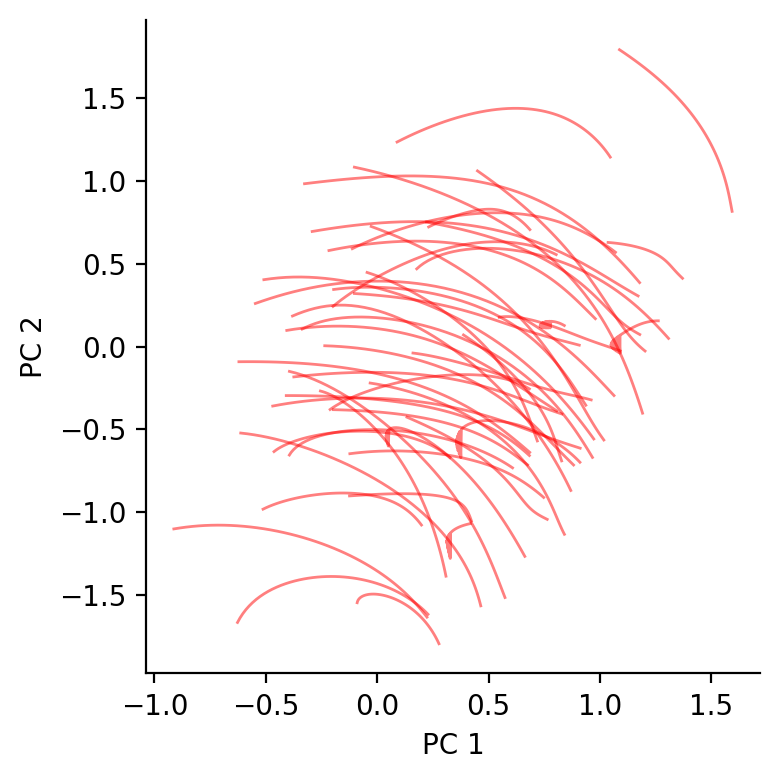

In [37]:
n_cells = 50
cell_idx = np.random.choice(trajectories.shape[1], n_cells, replace=False)

T = trajectories.shape[0]
sigma_t = max(3.0, 0.06 * T)  # time smoothing
sigma_c = 0.0                 # component smoothing (0 = no x↔y mixing)
truncate = 4.0
pad = int(truncate * sigma_t + 0.5)

plt.figure(figsize=(4,4))
for ci in cell_idx:
    # shape (2, T): rows = [x, y], cols = time
    xy = trajectories[:, ci, :2].T

    # 2D Gaussian filter (component, time)
    xy_s = gaussian_filter(xy, sigma=(sigma_c, sigma_t), mode="mirror", truncate=truncate)
    xs, ys = xy_s

    # optional: trim edges where padding dominates
    if pad < T // 2:
        xs, ys = xs[pad:-pad], ys[pad:-pad]

    sns.lineplot(x=xs, y=ys, lw=1, c='r', alpha=0.5,)

sns.despine()
plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.tight_layout()
plt.show()


In [5]:
break

SyntaxError: 'break' outside loop (668683560.py, line 1)

In [ ]:
plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 4, 4

sns.scatterplot(
    x = data[:, 0],
    y = data[:, 1],
    s=5,
    ec='none',
    hue=adata.obs['cluster_phase'], 
    palette=adata.uns['cluster_phase_colors'],
    legend=False,
)

plt.xticks([])
plt.yticks([])
sns.despine()

In [ ]:
def infer_vector_field(traj, n_neighbors=20, grid_size=40, step=1):
    """
    Infer v(x,y) from trajectories by local regression.
    traj: array of shape (T, C, 2) with positions over time.
    n_neighbors: K in KNN; larger -> smoother field.
    grid_size: number of points per axis for the output grid.
    step: time stride for finite difference (Δt = step).
    Returns: Xg, Yg, U, V, knn (fitted regressor)
    """
    assert traj.ndim == 3 and traj.shape[2] == 2, "traj must be (T, C, 2)"
    T, C, _ = traj.shape
    assert step >= 1 and step < T, "step must be in [1, T-1]"

    # positions at t and velocities (x_{t+step} - x_t) / step
    P = traj[:-step].reshape(-1, 2)                         # ( (T-step)*C, 2 )
    V = (traj[step:] - traj[:-step]).reshape(-1, 2) / step  # same shape
    V = -V

    # fit a multi-output KNN regressor: (x,y) -> (vx, vy)
    knn = KNeighborsRegressor(n_neighbors=n_neighbors, weights="distance")
    knn.fit(P, V)

    # grid over data support with small padding
    mins = P.min(axis=0); maxs = P.max(axis=0)
    span = maxs - mins
    pad = 0.05 * np.max(span)
    x_lin = np.linspace(mins[0]-pad, maxs[0]+pad, grid_size)
    y_lin = np.linspace(mins[1]-pad, maxs[1]+pad, grid_size)
    Xg, Yg = np.meshgrid(x_lin, y_lin)
    G = np.c_[Xg.ravel(), Yg.ravel()]

    UV = knn.predict(G)
    U = UV[:, 0].reshape(grid_size, grid_size)
    Vv = UV[:, 1].reshape(grid_size, grid_size)
    return Xg, Yg, U, Vv, knn

In [ ]:
x = data[:, 0]
y = data[:, 1]

sample_size = 500
n_neighbors = 5
grid_size = 35
step = 1
scale = 0.28


traj = trajectories.copy()
traj = traj[:, :, 0:2]
print(f"raw: {traj.shape=}")

cell_idx = np.random.choice(
    range(traj.shape[1]), 
    sample_size, 
    replace=False,
)

traj = traj[:, cell_idx, :]
print(f"sampled: {traj.shape=}")
Xg, Yg, U, V, model = infer_vector_field(
    traj, 
    n_neighbors=n_neighbors, 
    grid_size=grid_size, 
    step=step,
)

plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = (4, 4)

fig, ax = plt.subplots()

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 4, 4

sns.scatterplot(
    x=x, 
    y=y, s=4, 
    ec='none',
    hue=adata.obs['cluster_phase'], 
    palette=adata.uns['cluster_phase_colors'],
    alpha=0.35,
    legend=False,
    ax=ax,
)

ax.quiver(
    Xg, Yg, U, V, 
    angles='xy', 
    scale_units='xy', 
    scale=scale,
    pivot='tail', 
    color='k',
    alpha=0.8,
    headwidth=2.5,
)

# ---- bounds from data ----
xmin, xmax = np.nanmin(x), np.nanmax(x)
ymin, ymax = np.nanmin(y), np.nanmax(y)

ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)

plt.xticks([])
plt.yticks([])
sns.despine(bottom=True, left=True)